# Evaluation of Experiments

In [1]:
import os
import json

import numpy as np
import pylab as plt
import yaml

from pathlib import Path

In [ ]:
query_strategies = ['random', 'randomclust', 'entropy', 'leastconfidence', 'margin', 'coreset', 'badge', 'typiclust', 'alfamix', 'dropquery', 'falcun']
Q = {'random':'Random', 'randomclust': 'Random Clust', 'entropy':'Entropy', 'leastconfidence':'Least Confidence', 'margin':'Margin', 'coreset':'CoreSet', 'badge':'BADGE', 'typiclust':'TypiClust', 'alfamix':'AlfaMix', 'dropquery':'DropQuery', 'falcun':'FALCUN'}
seeds = ['seed_'+str(i) for i in range(1,11)]
datasets = ['CIFAR10', 'CIFAR100', 'SVHN', 'ImageNet']
results = {
    ds:{
        qs:{} for qs in query_strategies
        } for ds in datasets
}
root_path = Path('/home/phahn/repositories/dal-toolbox/examples/active_learning/server_experiments/server_results/baselines/dinov2/')

count = 0
for ds in datasets:
    for qs in query_strategies:
        paths = sorted(list(root_path.glob(ds+"/"+qs+"/*")))
        for path in paths:
            if os.path.exists(path / 'results.json'):
                count += 1
                with open(path / 'results.json', 'r') as f:
                    run_results = json.load(f)
                with open(path / '.hydra/config.yaml') as g:
                    conf = yaml.load(g, Loader=yaml.FullLoader)

                results[ds][qs][path.stem[-1]] = {'results': run_results, 'args': conf}
print(f"Number Runs: {count}/440.")

Number Runs: 187/440.


In [24]:
seeds = ['seed_'+str(i) for i in range(1,10)]

test_stats = {
    ds:{
    qs:{
        seed:{} for seed in seeds
        } for qs in query_strategies
        } for ds in datasets
}

for ds, resu in results.items():
    for qs, res in resu.items():
        metrics = {}
        for seed, r in res.items():
            seed = 'seed_'+seed
            if seed in seeds:
                for i_cyc in ['cycle'+str(i) for i in range(10 if ds == 'ImageNet' else 20)]:
                    cycle_results = r['results'][i_cyc]
                    for met, val in cycle_results['test_stats'].items():
                        if met not in test_stats[ds][qs][seed]:
                            test_stats[ds][qs][seed][met] = [val]
                        else:
                            test_stats[ds][qs][seed][met].append(val)

In [25]:
accs = {
    ds:{
    qs:[test_stats[ds][qs][i_seed]['accuracy'] for i_seed in seeds if 'accuracy' in test_stats[ds][qs][i_seed]] for qs in query_strategies
    } for ds in datasets
}

rand_accs = {ds:[test_stats[ds]['random'][i_seed]['accuracy'] for i_seed in seeds if 'accuracy' in test_stats[ds]['random'][i_seed]] for ds in datasets}

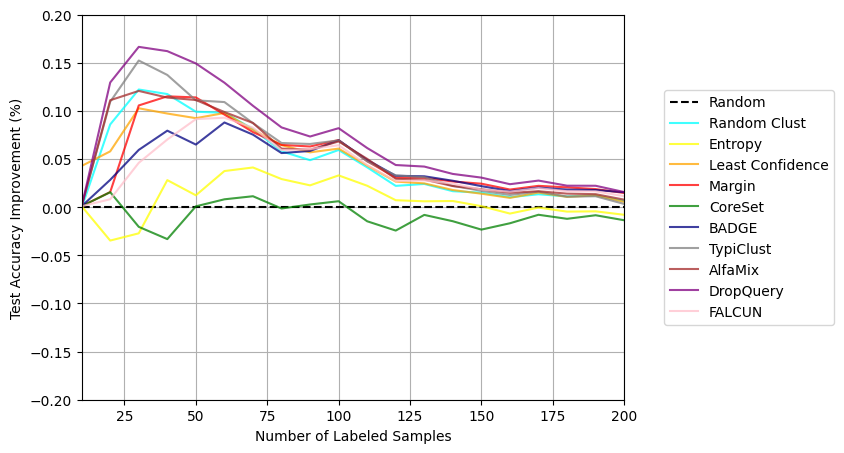

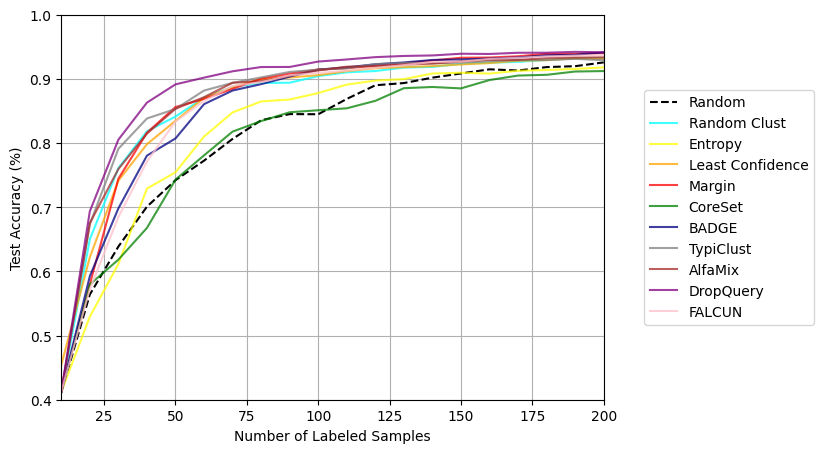

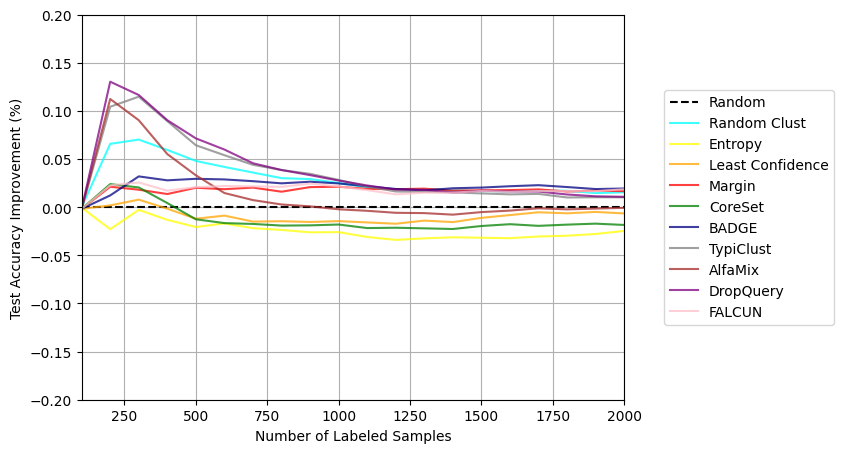

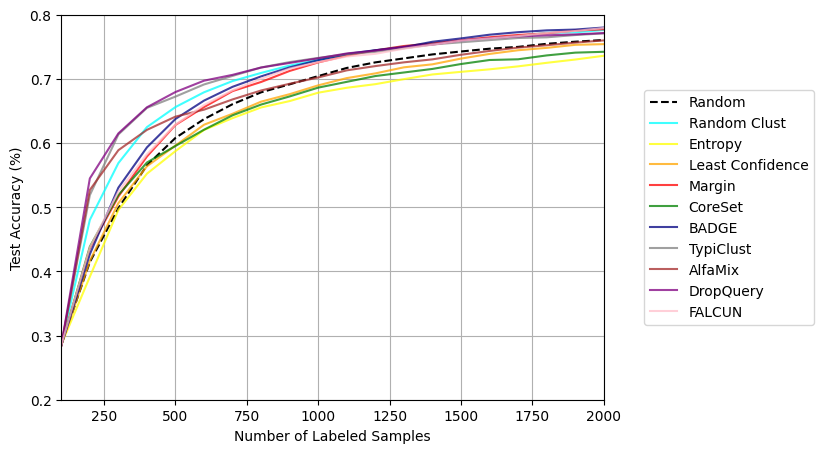

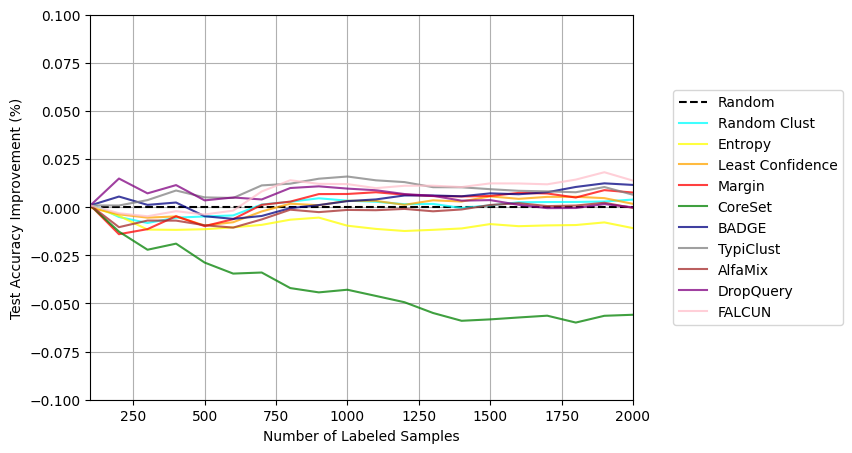

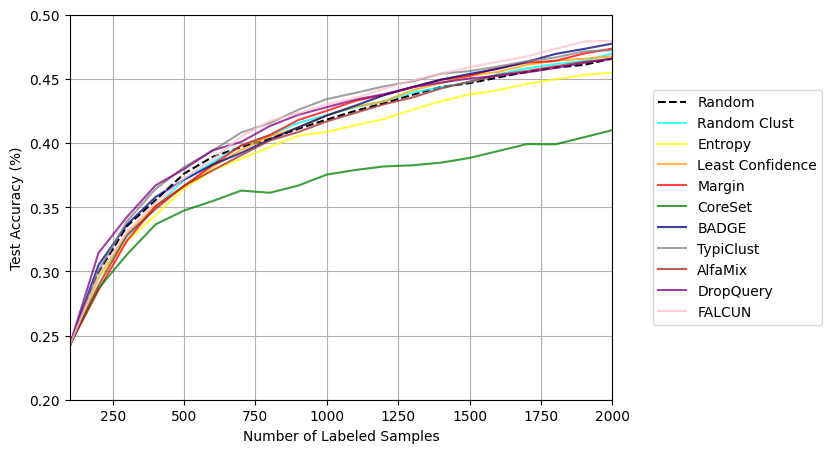

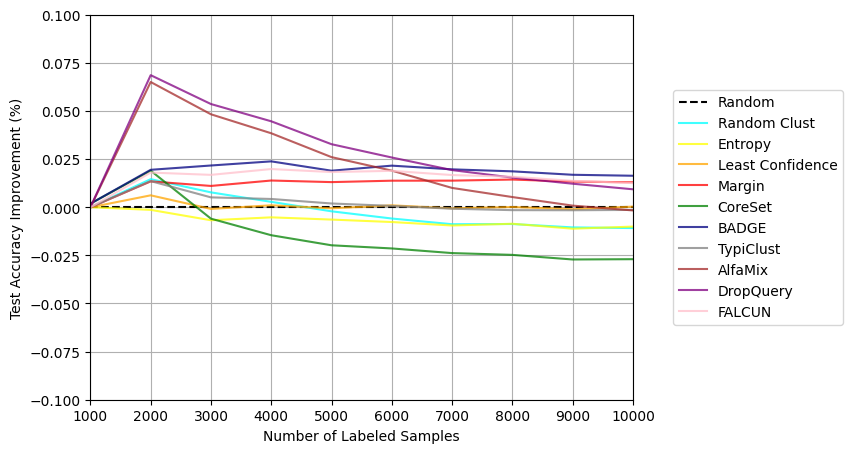

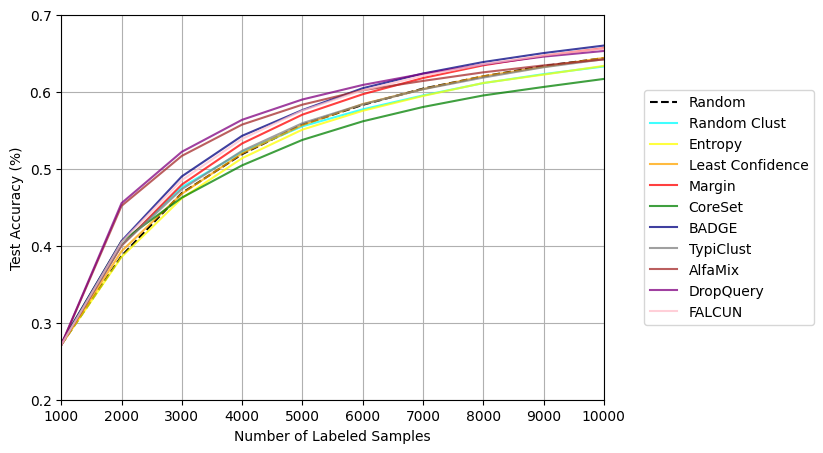

In [26]:
colors = ['royalblue', 'cyan', 'yellow', 'orange', 'red', 'green', 'navy', 'gray', 'brown', 'purple', 'pink']
save = False

for ds in datasets:
    query_size = {'CIFAR10' : 10, 'CIFAR100' : 100, 'SVHN' : 100, 'ImageNet' : 1000}[ds]
    n_queries = 10 if ds == 'ImageNet' else 20
    x_ticks = [query_size+i*query_size for i in range(n_queries)]
    plt.figure(figsize=(4, 3) if save else (7, 5))

    for i, qs in enumerate(query_strategies):
        if len(accs[ds][qs]) > 0:
            values = np.mean(accs[ds][qs], axis=0)-np.mean(rand_accs[ds], axis=0)
            if qs == 'random':
                plt.plot(x_ticks, values, label=Q[qs], alpha=1, linestyle='--', color='black')
            else:
                plt.plot(x_ticks, values, label=Q[qs], c=colors[i], alpha=0.75)
    lgd = plt.legend(bbox_to_anchor=[1.4, 0.5], loc='center right')
    plt.grid(True)
    plt.xlabel('Number of Labeled Samples')
    plt.ylabel('Test Accuracy Improvement (%)')
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim((-0.2, 0.2) if ds in 'CIFAR100' else (-0.1, 0.1))
    if save:
        plt.savefig('./plots/dinov2_'+ds+'_rel.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
    else:
        plt.show()

    plt.figure(figsize=(4, 3) if save else (7, 5))

    for i, qs in enumerate(query_strategies):
        if len(accs[ds][qs]) > 0:
            values = np.mean(accs[ds][qs], axis=0)
            if qs == 'random':
                plt.plot(x_ticks, values, label=Q[qs], alpha=1, linestyle='--', color='black')
            else:
                plt.plot(x_ticks, values, label=Q[qs], c=colors[i], alpha=0.75)
    lgd = plt.legend(bbox_to_anchor=[1.4, 0.5], loc='center right')
    plt.grid(True)
    plt.xlabel('Number of Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim({'CIFAR10':(0.4, 1), 'CIFAR100':(0.2, 0.8), 'SVHN':(0.2, 0.5), 'ImageNet' : (0.2, 0.7)}[ds])

    if save:
        plt.savefig('./plots/dinov2_'+ds+'_abs.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
    else:
        plt.show()